# MTG Analysis

### Using data provided from Scryfall, we learn about trends of a 25+ year game

Questions to look into:
- amount of vanilla cards per year
- increase in complexity (longer names more words)
- power creep average power/toughness per cmc
- what is the most used keyword

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_json("./MTG_JSON/oracle-cards-20260530090316.json")
print(df.head())
print(df.columns.tolist())

  object                                    id  \
0   card  a471b306-4941-4e46-a0cb-d92895c16f8a   
1   card  6b7baaa7-67f2-4902-a4c1-761d58cce1d4   
2   card  86bf43b1-8d4e-4759-bb2d-0b2e03ba7012   
3   card  7050735c-b232-47a6-a342-01795bfd0d46   
4   card  9c5e9b5f-6e71-4afc-abbd-ba4c788a3240   

                              oracle_id multiverse_ids   mtgo_id  \
0  00037840-6089-42ec-8c5c-281f9f474504       [692174]  137223.0   
1  000492bf-7eaa-4939-a51c-4eef74e4c1d1             []       NaN   
2  0004ebd0-dfd6-4276-b4a6-de0003e94237        [15862]   15870.0   
3  0006faf6-7a61-426c-9034-579f2cfcfa83       [370780]   49283.0   
4  00078ea3-0462-4a6e-b7b1-25fea012b2b7             []       NaN   

   tcgplayer_id  cardmarket_id                      name lang released_at  \
0      615195.0       807933.0  Nissa, Worldsoul Speaker   en  2025-02-14   
1           NaN            NaN             Mine Security   en  2025-08-19   
2        3094.0         3081.0                Static Orb   

In [3]:
# Ideas - vanilla cards are a dying species, average name length throughout the years, larger mana complexity?, power creep on power and defense per cmc, oricle changes compared to original, what set produced the most "gamechangers", what is the most used keyword in the game?


# Creatures Only
creatures_only_no_token = df.loc[df.type_line.str.contains("Creature —", na=False) & ~(df.layout.isin(["token", "double_faced_token"])) ]



print(creatures_only_no_token[["name", "set", "released_at", "reprint"]])



                                         name   set released_at  reprint
0                    Nissa, Worldsoul Speaker   drc  2025-02-14    False
1                               Mine Security  yeoe  2025-08-19    False
6                                  Storm Crow   9ed  2005-07-29     True
7                            Snarlfang Vermin  ymkm  2024-03-05    False
8                              Walking Sponge   ulg  1999-02-15    False
...                                       ...   ...         ...      ...
37467                            Devoted Hero   s99  1999-07-01     True
37468                         The Lion-Turtle   tla  2025-11-21    False
37470                 Firesong and Sunspeaker   2x2  2022-07-08     True
37471  Toralf, God of Fury // Toralf's Hammer   khm  2021-02-05    False
37473                            Sinew Sliver   cmm  2023-08-04     True

[18630 rows x 4 columns]


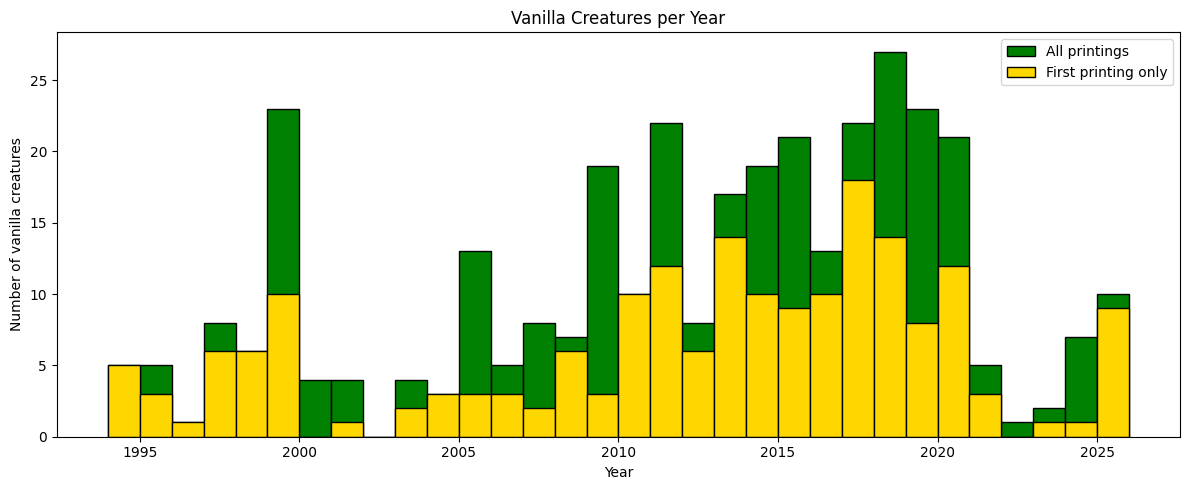

In [18]:
#Vanilla Creatures: creatures that have no special abilites
pure_vanilla_creatures =  creatures_only_no_token.loc[(creatures_only_no_token.oracle_text == "") & (creatures_only_no_token.keywords.str.len() == 0)]

pv_no_reprint = pure_vanilla_creatures.loc[ pure_vanilla_creatures.reprint == False]

years_all = pd.to_datetime(pure_vanilla_creatures["released_at"]).dt.year
years_no_reprint = pd.to_datetime(pv_no_reprint["released_at"]).dt.year

plt.figure(figsize=(12, 5))
bins = range(years_all.min(), years_all.max() + 2)
plt.hist(years_all, bins=bins, color="green", edgecolor="black", label="All printings")
plt.hist(years_no_reprint, bins=bins, color="gold", edgecolor="black", label="First printing only")

plt.title("Vanilla Creatures per Year")
plt.xlabel("Year")
plt.ylabel("Number of vanilla creatures")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# debug - Looking into 2001-2003 and seeing lack of vanilla creatures

for yr in [2001, 2002, 2003]:
    mask = pd.to_datetime(df.released_at).dt.year == yr
    creatures = df[mask & df.type_line.str.contains("Creature —", na=False)]
    print(f"\n{yr}:")
    print(f"  all creatures:        {len(creatures)}")
    print(f"  not reprint:          {(creatures.reprint == False).sum()}")
    print(f"  empty oracle_text:    {(creatures.oracle_text == '').sum()}")


2001:
  all creatures:        237
  not reprint:          203
  empty oracle_text:    4

2002:
  all creatures:        205
  not reprint:          203
  empty oracle_text:    0

2003:
  all creatures:        253
  not reprint:          207
  empty oracle_text:    4


keywords
Flying                  2130
Trample                  739
Vigilance                539
Haste                    500
Menace                   335
                        ... 
Psychic Abomination        1
Enmitic Exterminator       1
Sonic Rainboom             1
Glory of Battle            1
Grenades!                  1
Name: count, Length: 597, dtype: int64


<Figure size 1200x500 with 0 Axes>

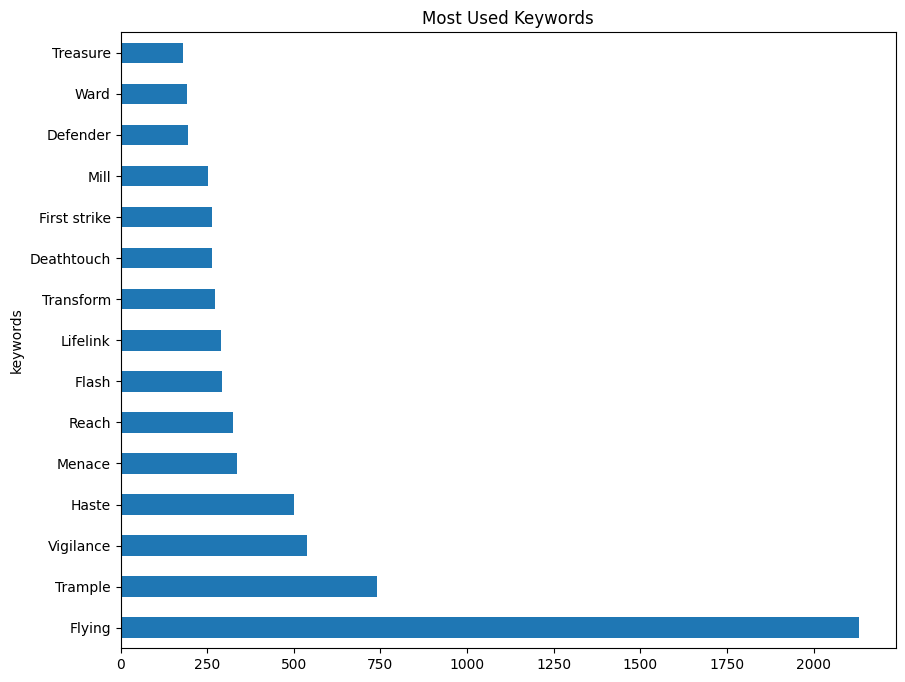

In [16]:
# Most used keyword
c_no_token_no_reprint = creatures_only_no_token.loc[ df.reprint == False ]
plt.figure(figsize=(12, 5))

keyword_counts = c_no_token_no_reprint['keywords'].explode().value_counts()
print(keyword_counts)
plt.figure(figsize=(12, 5))
keyword_counts.head(15).plot.barh(figsize=(10, 8))
plt.title("Most Used Keywords")
plt.show()

In [ ]:
# power creep average power/toughness per cmc


